# 1. Realizando a importação das bibliotecas que serão utilizadas ao longo do projeto

As bibliotecas que serão utilizadas são: Pandas, matplotlib e seaborn. Caso ainda não tenha instaldo localmente algumas dessas bibliotecas rode a celular abaixo:

In [ ]:
!python -m pip install pandas matplotlib seaborn numpy
print("Dependencias instaladas com sucesso")

Com todas as dependencias necessarias instaladas, podemos prosseguir

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('Superstore.csv', encoding='cp1252')
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

# Evolução das vendas e do lucro ao longo do tempo
Objetivo: Descobrir o crescimento das vendas, sazonalidade, meses fortes e fracos

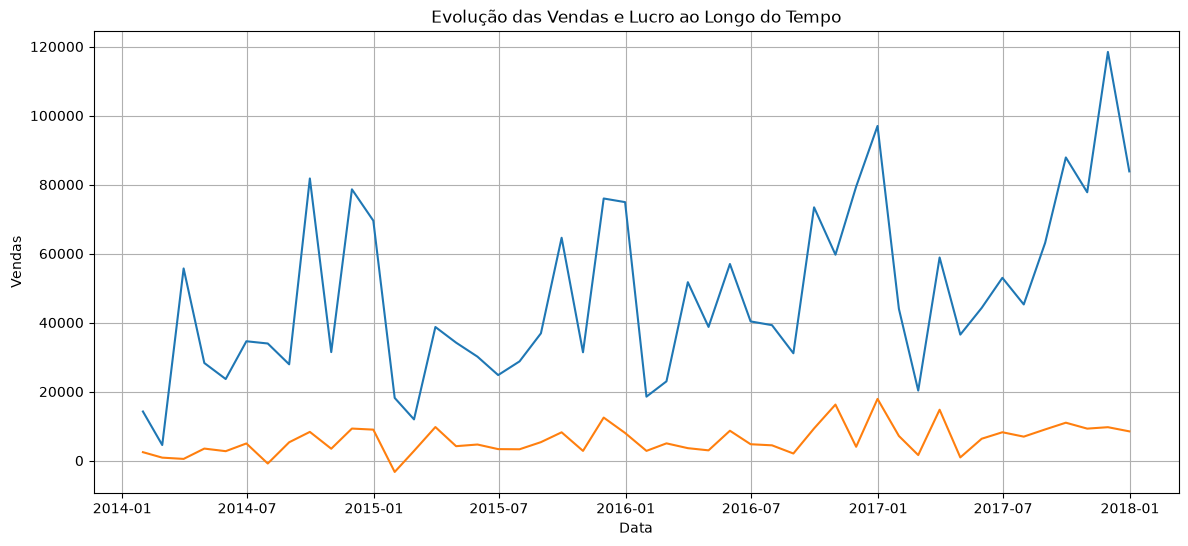

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df_month = df.groupby(pd.Grouper(key='Order Date', freq='ME')).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

plt.figure(figsize=(14,6))

plt.plot(df_month['Order Date'], df_month['Sales'], label='Vendas')
plt.plot(df_month['Order Date'], df_month['Profit'], label='Lucro')

plt.title('Evolução das Vendas e Lucro ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Vendas')
plt.grid(True)
plt.show()


# Vendas e Lucro por categoria
Objetivo: Por mais que já sabemos a relação entre vendas e lucro com base no gráfico anterior, qual é a categoria que vende mais? Qual é a categoria que gera mais lucro? Existe alguma que vende muito, mas lucra pouco?

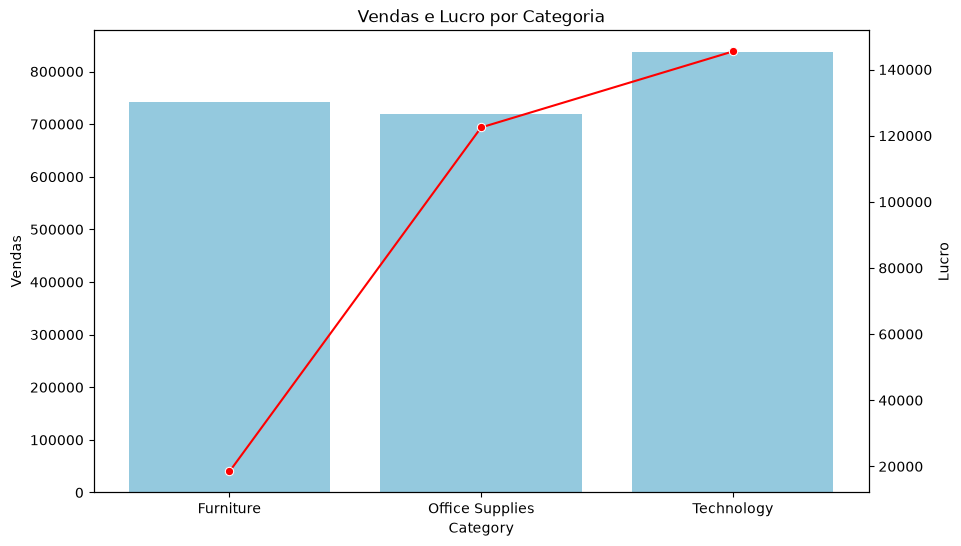

In [ ]:
#agrupando as categorias e somando os valores de venda e lucro de cada uma
category_summary = (
    df.groupby('Category')
      .agg({
          'Sales': 'sum',
          'Profit': 'sum'
      })
      .reset_index()
)


fig, ax1 = plt.subplots(figsize=(10,6))

#criando o gráfico de barras
sns.barplot(
    data=category_summary,
    x='Category',
    y='Sales',
    ax=ax1,
    color='skyblue'
)

#cria um outro eixo Y usando o mesmo eixo X de ax1
ax2 = ax1.twinx()

#linha do lucro
sns.lineplot(
    data=category_summary,
    x='Category',
    y='Profit',
    marker='o',
    ax=ax2,
    color='red'
)

ax1.set_ylabel("Vendas")
ax2.set_ylabel("Lucro")
plt.title("Vendas e Lucro por Categoria")
plt.show()

# Lucro e prejuizo das sub-categorias
Já sabemos a relação entre vendas e lucro das categorias, mas no dataset há também sub-categorias. Podemos analisa-las para verificar aquelas que possuem os melhores lucros e as que geram prejuizos

Text(0.5, 1.0, 'Margem de Lucro por Subcategoria')

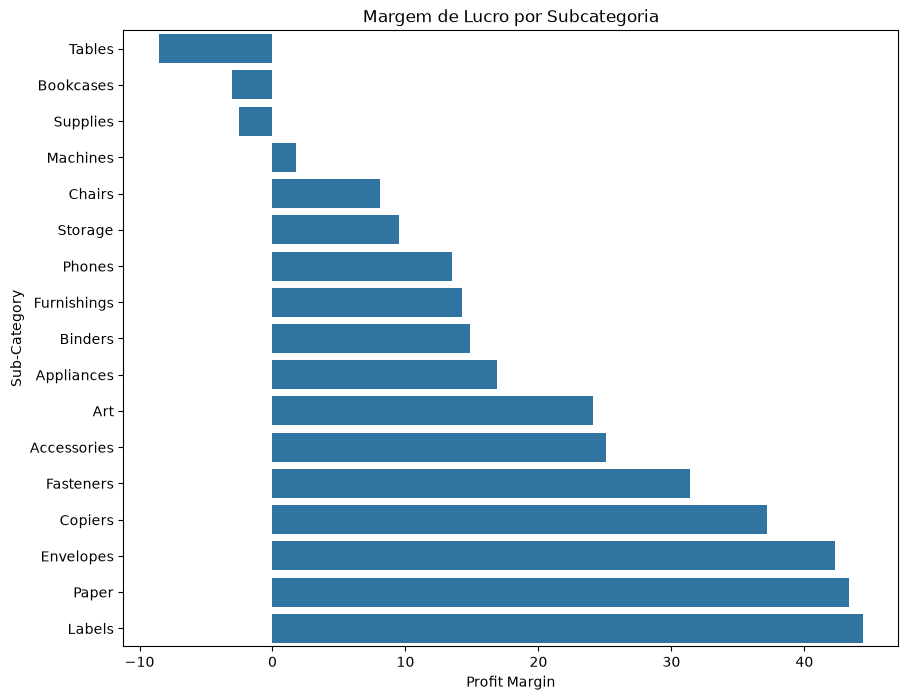

In [ ]:
sub_category_summary = (
    df.groupby('Sub-Category')
      .agg({
          'Sales': 'sum',
          'Profit': 'sum'
      })
      .reset_index()
)

#criando a metrica de margem
sub_category_summary['Profit Margin'] = (
    sub_category_summary['Profit']
    / sub_category_summary['Sales']
) * 100

plt.figure(figsize=(10,8))

#gera o grafico ordenando com base na margem
sns.barplot(
    data=sub_category_summary.sort_values('Profit Margin'),
    x='Profit Margin',
    y='Sub-Category'
)

plt.title("Margem de Lucro por Subcategoria")

# Impacto do desconto sobre o lucro
Objetivo: Analisar se oferecer descontos realmente vale a pena e impacta positivamente no lucro

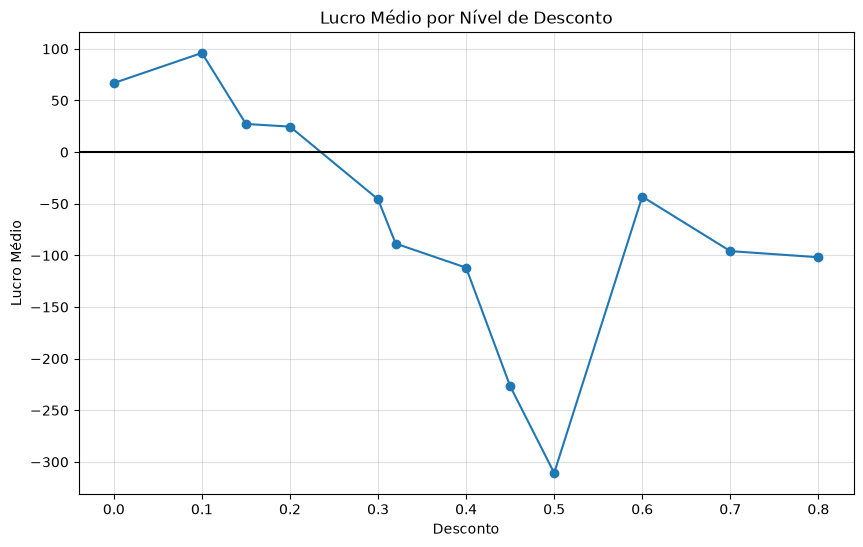

In [12]:
discount_profit = (
    df.groupby('Discount')['Profit']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))

plt.plot(
    discount_profit['Discount'],
    discount_profit['Profit'],
    marker='o'
)

plt.axhline(0, linestyle='-', color='black')

plt.title('Lucro Médio por Nível de Desconto')
plt.xlabel('Desconto')
plt.ylabel('Lucro Médio')
plt.grid(alpha=0.4)

plt.show()

# Clientes especiais
Quais são os clientes que mais compram?
Quanto os top 20 clientes representam do faturamento total?

C:\Users\segan\AppData\Local\Temp\ipykernel_456\2458117226.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


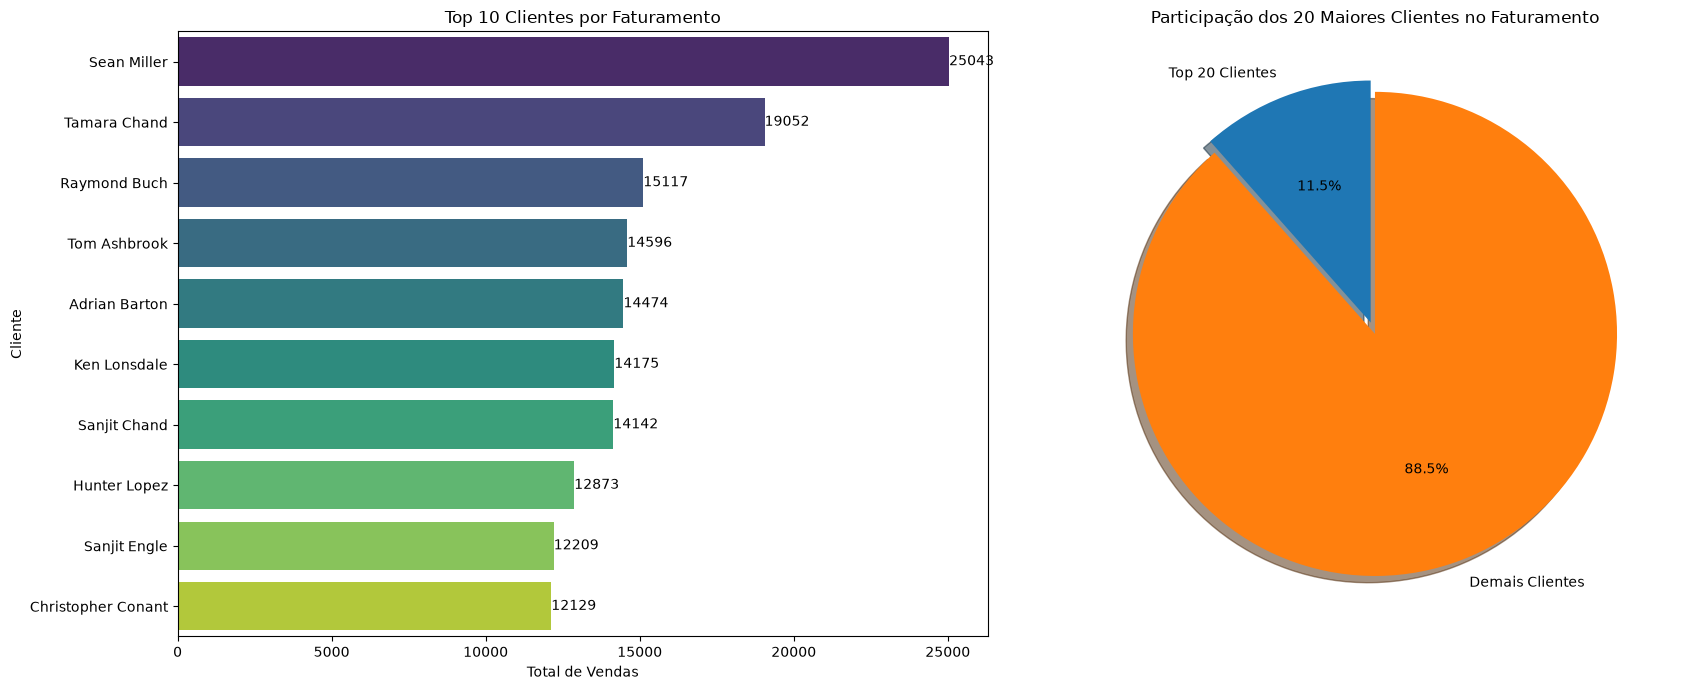

In [5]:
customer_summary = (
    df.groupby('Customer Name')
      .agg({
          'Sales': 'sum',
          'Profit': 'sum'
      })
      .sort_values(by='Sales', ascending=False)
      .reset_index()
)

# Top 10 clientes por vendas
top10 = customer_summary.head(10)

# Faturamento dos 20 maiores clientes
top20_sales = customer_summary.head(20)['Sales'].sum()

# Faturamento total
total_sales = customer_summary['Sales'].sum()

# Restante dos clientes
other_sales = total_sales - top20_sales

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#grafico top 10 clientes
sns.barplot(
    data=top10,
    x='Sales',
    y='Customer Name',
    palette='viridis',
    ax=axes[0]
)

axes[0].set_title('Top 10 Clientes por Faturamento')
axes[0].set_xlabel('Total de Vendas')
axes[0].set_ylabel('Cliente')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f')


#grafico de pizza
axes[1].pie(
    [top20_sales, other_sales],
    labels=['Top 20 Clientes', 'Demais Clientes'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0),
    shadow=True
)

axes[1].set_title('Participação dos 20 Maiores Clientes no Faturamento')

plt.tight_layout()
plt.show()

# Analise Regional
Vamos buscar analisar a quantidade de vendas e de lucro por região

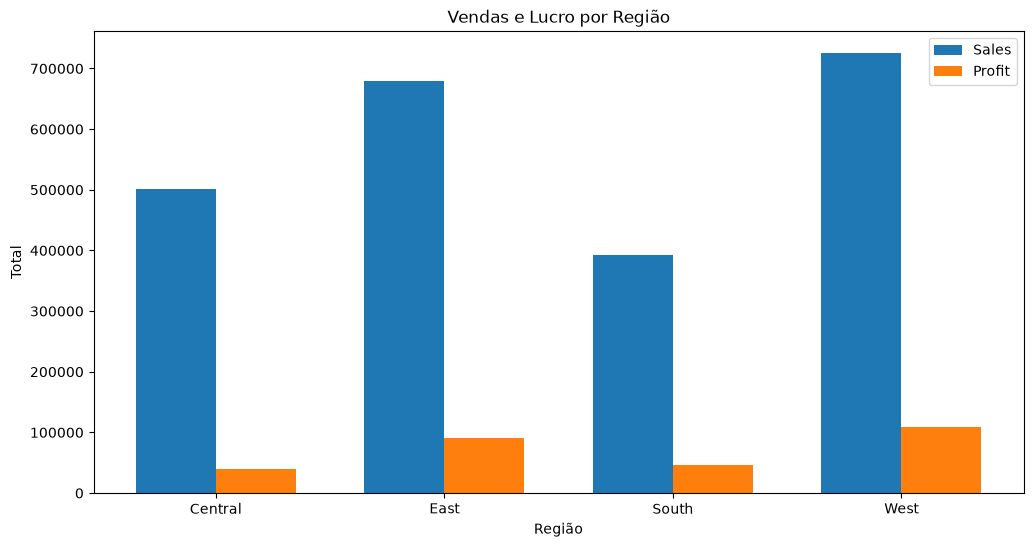

In [6]:
sales_region = df.groupby('Region')['Sales'].sum()
profit_region = df.groupby('Region')['Profit'].sum()

# Posições das barras
x = np.arange(len(sales_region))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, sales_region.values, width, label='Sales')
plt.bar(x + width/2, profit_region.values, width, label='Profit')

plt.xticks(x, sales_region.index)
plt.title('Vendas e Lucro por Região')
plt.xlabel('Região')
plt.ylabel('Total')
plt.legend()

plt.show()

# Estados mais lucrativos e estados com prejuízo

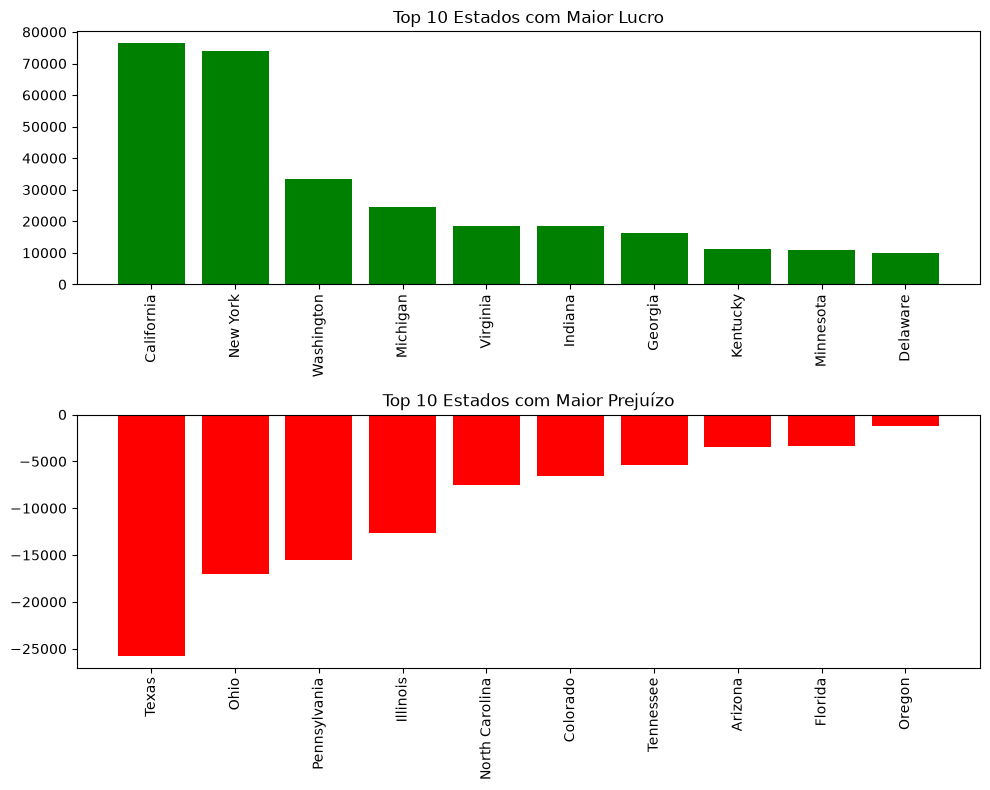

In [55]:
# Lucro por estado
profit_state = df.groupby('State')['Profit'].sum()

# Top 10 maiores lucros
top_profit = profit_state.sort_values(ascending=False).head(10)

# Top 10 maiores prejuízos
top_loss = profit_state.sort_values().head(10)

plt.figure(figsize=(10,8))

# Primeiro gráfico
plt.subplot(2,1,1)
plt.bar(top_profit.index, top_profit.values, color='green')
plt.title("Top 10 Estados com Maior Lucro")
plt.xticks(rotation=90)

# Segundo gráfico
plt.subplot(2,1,2)
plt.bar(top_loss.index, top_loss.values, color='red')
plt.title("Top 10 Estados com Maior Prejuízo")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Logística
Iremos analisar tempo de entrega com base no tempo de entrega, para assim sabermos se há um tipo específico de entrega que leva mais tempo

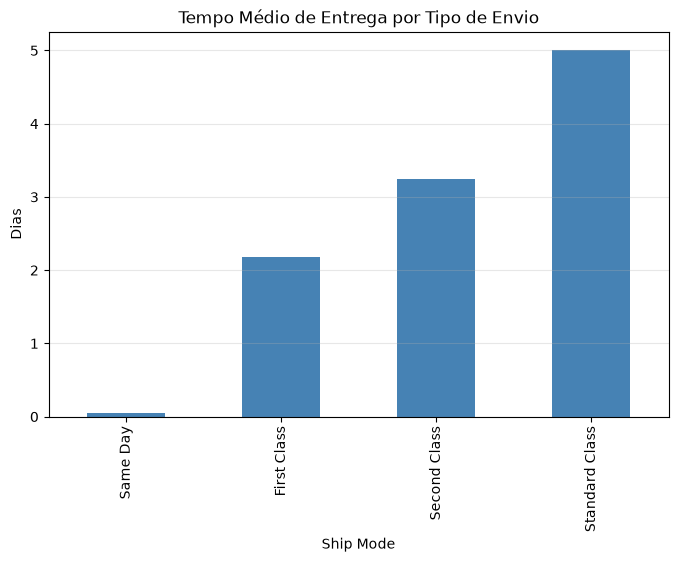

In [66]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Delivery Time'] = df['Ship Date'] - df['Order Date']
df['Delivery Time'] = df['Delivery Time'].dt.days

delivery_mean = df.groupby('Ship Mode')['Delivery Time'].mean()

delivery_mean.sort_values().plot(
    kind='bar',
    figsize=(8,5),
    color='steelblue'
)

plt.title('Tempo Médio de Entrega por Tipo de Envio')
plt.xlabel('Ship Mode')
plt.ylabel('Dias')
plt.grid(axis='y', alpha=0.3)

plt.show()


Text(0, 0.5, 'Dias')

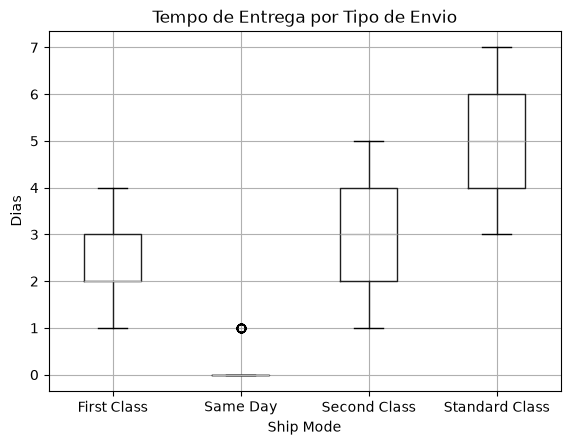

In [67]:
df.boxplot(column='Delivery Time', by='Ship Mode')

plt.title('Tempo de Entrega por Tipo de Envio')
plt.suptitle('')
plt.xlabel('Ship Mode')
plt.ylabel('Dias')